# 🎨 Learning Visualization with SkillCorner Open Data

This notebook demonstrates how to **use and apply the SkillCorner visualization library** with data from the A-League 24/25 season.

You can find an online version of this notebook here: https://colab.research.google.com/drive/1frYsXKaH8jhJOTwHPFDi78Dmjunwd2Jh

## 📋 Step 1: Setup & Prerequisites

In [ ]:
# Install libraries
!pip install skillcornerviz
!pip install skillcorner

# Import visualizations
from skillcornerviz.standard_plots import bar_plot as bar
from skillcornerviz.standard_plots import scatter_plot as scatter
from skillcornerviz.standard_plots import swarm_violin_plot as svp
from skillcornerviz.standard_plots import radar_plot as rad

## 📥 Step 2: Load Physical Data

In [ ]:
# Option 1: Fork opendata github repo and work in your local environment
# Link to repo: https://github.com/SkillCorner/opendata

In [ ]:
# Option 2: Load Physical CSV file directly from Github Open Data below

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Note the change to 'raw.githubusercontent.com' and the removal of '/blob/'
url = "https://raw.githubusercontent.com/SkillCorner/opendata/master/data/aggregates/aus1league_physicalaggregates_20242025.csv"

physical_df = pd.read_csv(url)
physical_df.head()


,player_name,player_short_name,player_id,player_birthdate,team_name,team_id,competition_name,competition_id,season_name,season_id,...,sprint_distance_full_otip,sprint_count_full_otip,hi_distance_full_otip,hi_count_full_otip,medaccel_count_full_otip,highaccel_count_full_otip,meddecel_count_full_otip,highdecel_count_full_otip,explacceltohsr_count_full_otip,explacceltosprint_count_full_otip
0,Adam Taggart,A. Taggart,211,1993-06-02,Perth Glory Football Club,871,AUS - A-League,61,2024/2025,95,...,48.46,3.00,297.83,27.21,42.38,2.67,38.25,6.96,1.92,0.08
1,Adama Traoré,A. Traoré,218,1990-02-03,Melbourne Victory Football Club,868,AUS - A-League,61,2024/2025,95,...,69.67,4.00,315.33,25.00,37.83,2.00,25.67,4.50,1.17,0.50
2,Dino Arslanagić,D. Arslanagić,2759,1993-04-24,Macarthur FC,1804,AUS - A-League,61,2024/2025,95,...,29.12,1.25,223.25,16.88,45.12,1.75,30.75,3.50,1.25,0.00
3,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,28.00,2.00,227.25,17.50,28.75,2.00,25.00,3.00,0.75,0.25
4,Douglas Costa de Souza,Douglas Costa,2858,1990-09-14,Sydney Football Club,869,AUS - A-League,61,2024/2025,95,...,1.00,0.00,170.00,16.00,26.00,0.00,21.00,2.00,0.00,0.00


In [ ]:
# Explore unique columns
physical_df.columns.unique()

Index(['player_name', 'player_short_name', 'player_id', 'player_birthdate',
       'team_name', 'team_id', 'competition_name', 'competition_id',
       'season_name', 'season_id', 'position_group', 'minutes_full_all',
       'minutes_full_tip', 'minutes_full_otip', 'count_match',
       'count_match_failed', 'total_distance_full_all',
       'total_metersperminute_full_all', 'running_distance_full_all',
       'hsr_distance_full_all', 'hsr_count_full_all',
       'sprint_distance_full_all', 'sprint_count_full_all',
       'hi_distance_full_all', 'hi_count_full_all', 'medaccel_count_full_all',
       'highaccel_count_full_all', 'meddecel_count_full_all',
       'highdecel_count_full_all', 'explacceltohsr_count_full_all',
       'timetohsr_top3', 'explacceltosprint_count_full_all',
       'timetosprint_top3', 'psv99', 'psv99_top5', 'total_distance_full_tip',
       'total_metersperminute_full_tip', 'running_distance_full_tip',
       'hsr_distance_full_tip', 'hsr_count_full_tip',
       

In [ ]:
# Explore position groups
physical_df['position_group'].unique()

array(['Center Forward', 'Full Back', 'Central Defender', 'Midfield',
       'Wide Attacker'], dtype=object)

In [ ]:
# Explore teams
physical_df['team_name'].unique()

array(['Perth Glory Football Club', 'Melbourne Victory Football Club',
       'Macarthur FC', 'Sydney Football Club', 'Auckland FC',
       'Adelaide United Football Club', 'Western Sydney Wanderers FC',
       'Wellington Phoenix FC', 'Melbourne City FC',
       'Central Coast Mariners Football Club', 'Western United',
       'Newcastle United Jets FC', 'Brisbane Roar FC'], dtype=object)

## 📊 Step 3: Normalize Data

The raw data in this dataset consists of cumulative season totals. To compare players fairly regardless of how many matches they started or their total playing time, we must normalize these figures into Per 90 (P90) or Per 60 (P60) metrics. The P60 metric combines TIP (Team in Possession) and OTIP (Opponent Team In Possession) numbers to get "Ball In Play" Time.

**Per 90 Minutes**

Example:
(hi_count_full_all / minutes_full_all) * 90

**Per 60 Minutes Ball in Play (BIP)**

Example:
(count_hi_full_tip+count_hi_full_otip)*60/(minutes_full_tip+minutes_full_otip)

**Matches Played**

We use a minimum treshold of 5 games when comparing players physical data

In [ ]:
# Filter dataframe, physical_df for minimum 5 games
physical_df = physical_df[physical_df['count_match'] >= 5 ]

# Normalizing metrics Per 90
physical_df['hi_count_p90'] = (physical_df['hi_count_full_all'] / physical_df['minutes_full_all']) * 90
physical_df['distance_p90'] = (physical_df['total_distance_full_all'] / physical_df['minutes_full_all']) * 90

# Normalizing metrics Per 60 BIP
physical_df['explosive_accels_to_sprint_p60'] = (physical_df['explacceltosprint_count_full_tip'] + physical_df['explacceltosprint_count_full_otip']) * 60 / (physical_df['minutes_full_tip'] + physical_df['minutes_full_otip'])

In [ ]:
#checking that new metrics have been included in physical_df
physical_df.columns.unique()

Index(['player_name', 'player_short_name', 'player_id', 'player_birthdate',
       'team_name', 'team_id', 'competition_name', 'competition_id',
       'season_name', 'season_id', 'position_group', 'minutes_full_all',
       'minutes_full_tip', 'minutes_full_otip', 'count_match',
       'count_match_failed', 'total_distance_full_all',
       'total_metersperminute_full_all', 'running_distance_full_all',
       'hsr_distance_full_all', 'hsr_count_full_all',
       'sprint_distance_full_all', 'sprint_count_full_all',
       'hi_distance_full_all', 'hi_count_full_all', 'medaccel_count_full_all',
       'highaccel_count_full_all', 'meddecel_count_full_all',
       'highdecel_count_full_all', 'explacceltohsr_count_full_all',
       'timetohsr_top3', 'explacceltosprint_count_full_all',
       'timetosprint_top3', 'psv99', 'psv99_top5', 'total_distance_full_tip',
       'total_metersperminute_full_tip', 'running_distance_full_tip',
       'hsr_distance_full_tip', 'hsr_count_full_tip',
       

## 🎨 Step 4: Visualize Data

### 4.1 Bar Chart

**PSV-99** stands for Peak Speed Velocity at the 99th percentile of the speed distribution, specifically considering speeds between 15 km/h and 40 km/h.

PSV-99 is not equivalent to the actual peak speed; it is typically lower than the real peak speed.

A high PSV-99 indicates an ability to repeat sprints at high velocity.

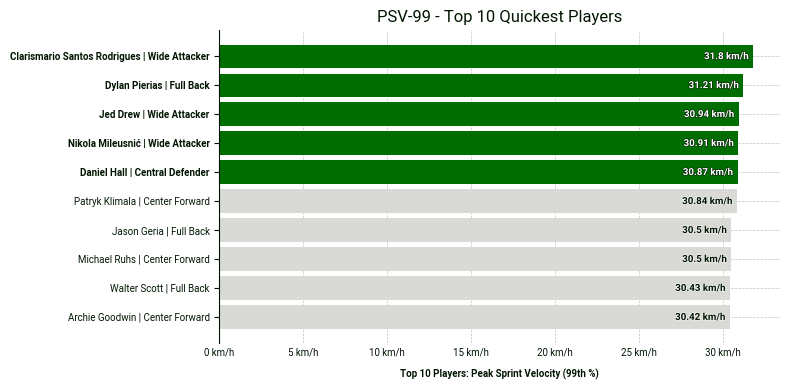

In [ ]:
# 1. Sort by the metric and take the top 10
# Using 'psv_99' which is the column name
top_10_physical = physical_df.sort_values('psv99', ascending=False).head(10).copy()

# 2. Create the custom plot label (Name | Position)
# This combines the player name and their role for the Y-axis
top_10_physical['plot_label'] = (
    top_10_physical['player_name'] + ' | ' + top_10_physical['position_group']
)

# 3. Automatically get the IDs of the top 5 to highlight them in green
top_5_ids = top_10_physical['player_id'].head(5).tolist()

# 4. Create the bar plot
fig, ax = bar.plot_bar_chart(
    physical_df=top_10_physical,
    metric='psv99',
    label='Top 10 Players: Peak Sprint Velocity (99th %)',
    unit='km/h',
    primary_highlight_group=top_5_ids,   # These 5 will be green
    primary_highlight_color='#006D00',    # SkillCorner Green
    add_bar_values=True,
    data_point_id='player_id',           # Matches the IDs in top_5_ids
    data_point_label='plot_label',       # Uses the 'Name | Position' string
    plot_title='PSV-99 - Top 10 Quickest Players'
)

### 4.2 Swarm Plot

Here, we are looking at PSV-99 split by position groups on a team-level.

/usr/local/lib/python3.12/dist-packages/skillcornerviz/standard_plots/swarm_violin_plot.py:249: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(y_group_labels,


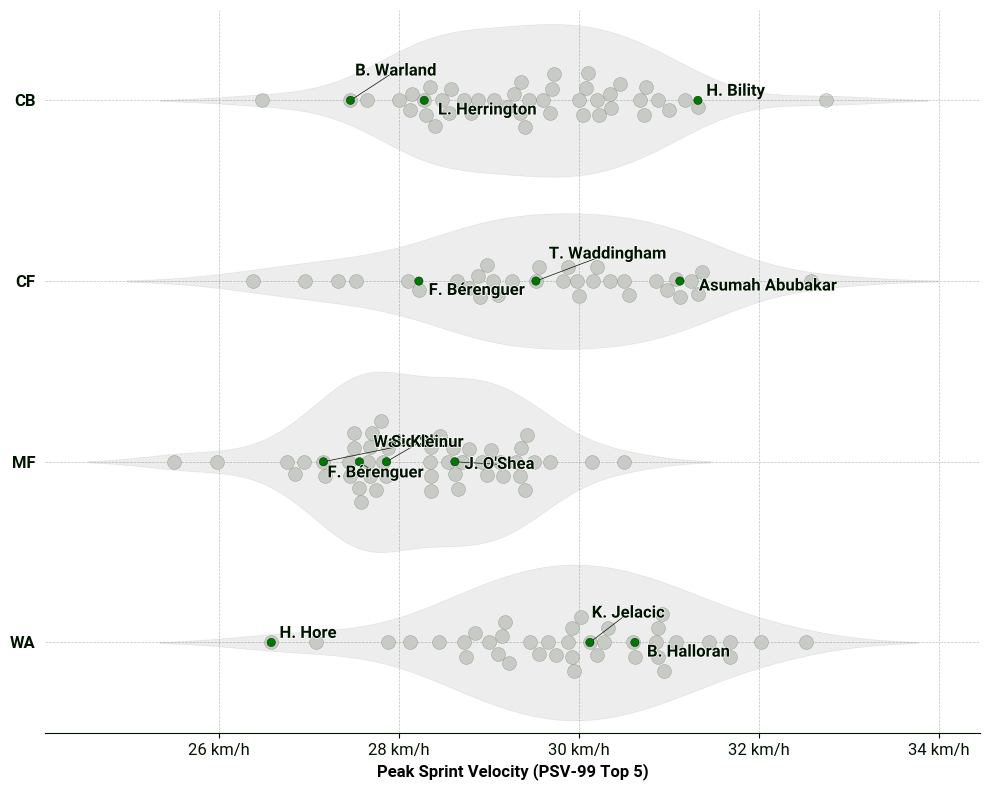

In [ ]:
# 1. Define Labels and Units
x_label = 'Peak Sprint Velocity (PSV-99 Top 5)'
x_unit = 'km/h'
y_labels = ['CB', 'CF', 'MF', 'WA']

# 2. SIMPLE TEAM INPUT: Just change the team name here
target_team = 'Brisbane Roar FC'
team_ids = physical_df[physical_df['team_name'] == target_team]['player_id'].tolist()

# 3. Create the Swarm-Violin Plot
fig, ax = svp.plot_swarm_violin(
    physical_df=physical_df,
    x_metric='psv99_top5',
    y_metric='position_group',
    y_groups=['Central Defender','Center Forward', 'Midfield', 'Wide Attacker'],
    x_label=x_label,
    y_group_labels=y_labels,
    x_unit=x_unit,
    data_point_id='player_id',
    data_point_label='player_short_name',

    # Highlights the entire team based on the name above
    # Adjust fig size and fonts as you wish
    secondary_highlight_group=team_ids,
    point_size=14,
    figsize=(10, 8),
    fontsize= 12,
    label_fontsize=12
    )

plt.show()

### 4.3 Scatter Plot

Let's filter for attackers and plot their PSV-99 and frequency of High Intensity Activities Per 90 Minutes.

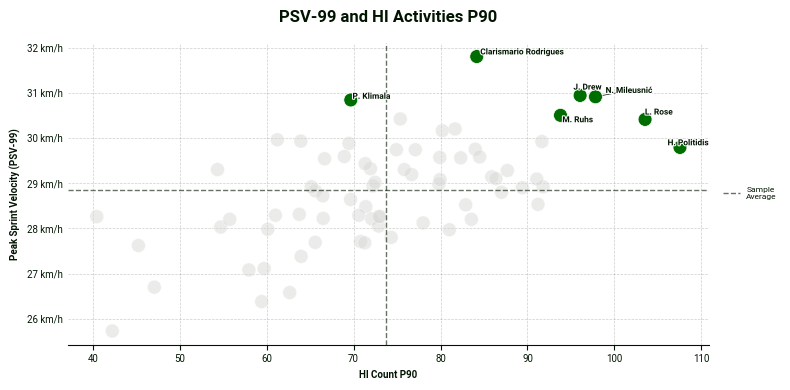

In [ ]:
# Filter for Attackers
attackers_df = physical_df[physical_df['position_group'].isin(['Wide Attacker', 'Center Forward'])].copy()

# Identify the Top 5 in each category
top_5_speed_ids = attackers_df.sort_values('psv99', ascending=False).head(5)['player_id'].tolist()
top_5_volume_ids = attackers_df.sort_values('hi_count_p90', ascending=False).head(5)['player_id'].tolist()

# Combine both lists and remove duplicates
highlight_players = list(set(top_5_speed_ids + top_5_volume_ids))

# 2. Calculate Averages lines
hi_count_avg = attackers_df['hi_count_p90'].mean()
psv_avg = attackers_df['psv99'].mean()

# 3. Create the scatter plot
fig, ax = scatter.plot_scatter(
    physical_df=attackers_df,
    x_metric='hi_count_p90',
    y_metric='psv99',
    data_point_id='player_id',
    primary_highlight_group=highlight_players, #list of data point ids to highlight
    data_point_label='player_short_name',
    x_label='HI Count P90',
    y_label='Peak Sprint Velocity (PSV-99)',
    y_unit='km/h',
    primary_highlight_color='#006D00',
    plot_title='PSV-99 and HI Activities P90'
)

### 4.4 Radar Chart

Here, we want to display a player's physical profile in a radar chart.

Radar plots are typically used for off-ball runs but in this case we applied it to the physical data.

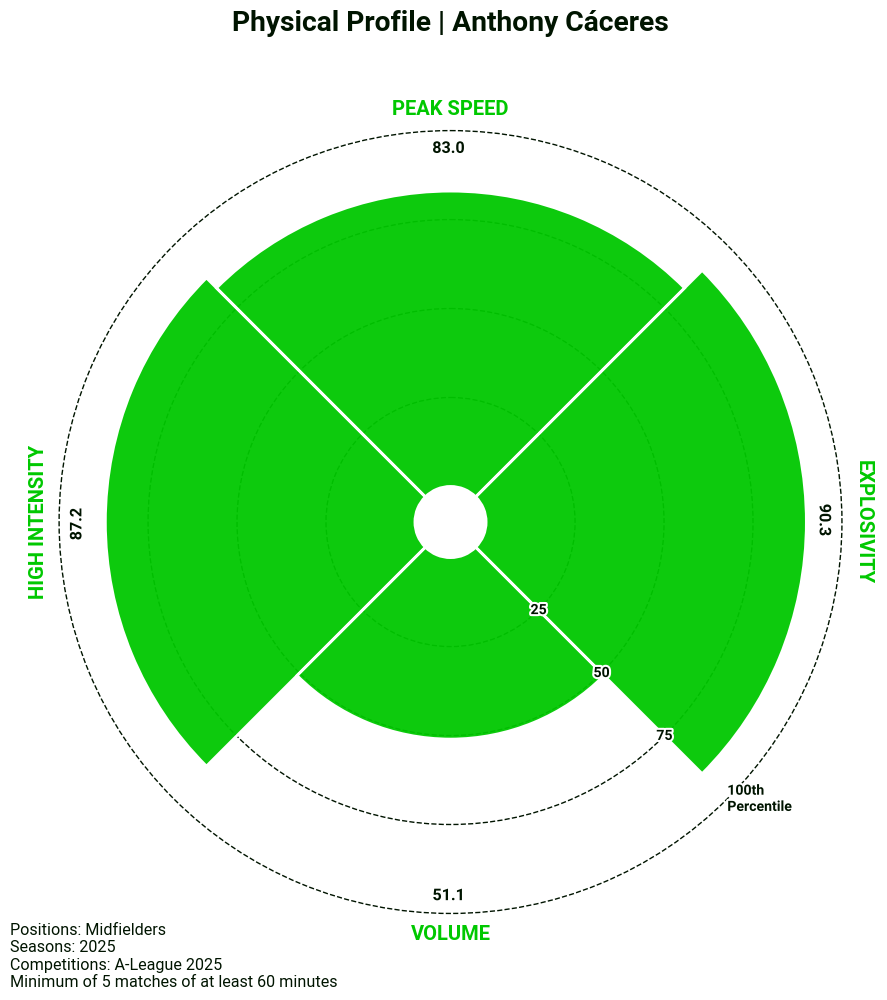

In [ ]:
radar_df = physical_df[physical_df['position_group'] == 'Midfield'].copy()

PHYSICAL = {'hi_count_p90': 'High Intensity',
        'psv99': 'Peak Speed',
        'timetosprint_top3': 'Explosivity',
        'distance_p90': 'Volume'}

# Percentile Ranking (invert relevant ones)
lower_is_better = ['timetosprint_top3']
higher_is_better = ['hi_count_p90', 'psv99', 'distance_p90']

for metric in lower_is_better:
    # ascending=False ensures the LOWEST time gets the HIGHEST percentile
    radar_df[metric] = radar_df[metric].rank(pct=True, ascending=False) * 100

for metric in higher_is_better:
    # Standard percentile calculation (Higher value = Higher percentile)
    radar_df[metric] = radar_df[metric].rank(pct=True) * 100


# Plot off-ball run radar for x player
fig, ax = rad.plot_radar(radar_df,
                         data_point_id='player_name', # can also use player_id as data_point_id
                         label="Anthony Cáceres", # insert player
                         plot_title='Physical Profile | Anthony Cáceres',
                         metrics=PHYSICAL.keys(),
                         metric_labels=PHYSICAL,
                         suffix=' ',

                         # Create your own sample text
                         positions='Midfielders',
                         matches=5,
                         minutes=60,
                         competitions='A-League 2025',
                         seasons='2025', add_sample_info=True)

In [ ]:
# Read and explore more about our physical data here: https://skillcorner.com/products/football/physical-data